In [1]:
import pandas as pd

# Read the LEAPQ data
leapq = pd.read_csv(r'C:\Users\Aditi\ds005613\derivatives\nebula_101_leapq_data.tsv', sep='\t')
print(leapq.shape)
print(leapq.columns.tolist())
print(leapq.head(3))

(101, 490)
['participant_id', 'age', 'nlang', 'sex', 'edu', 'entropy_competence_speak', 'entropy_competence_read', 'entropy_competence_compr', 'entropy_curr_tot_exp', '1langname_dominance', '1env_country', '1env_fam', '1env_eduwrk', '1env_other', '1speak_choice', '1read_choice', '1curr_tot_exp', '1ageof_acq', '1ageof_speak', '1ageof_read', '1ageof_read_fl', '1timespent_country', '1timespent_fam', '1timespent_eduwrk', '1timespent_other', '1competence_speak', '1competence_compr', '1competence_read', '1contrib_friends', '1contrib_fam', '1contrib_read', '1contrib_apps', '1contrib_video', '1contrib_audio', '1contrib_life', '1contrib_edu', '1curr_exp_friends', '1curr_exp_fam', '1curr_exp_read', '1curr_exp_apps', '1curr_exp_video', '1curr_exp_audio', '1curr_exp_life', '1curr_exp_edu', '1foreign_acc', '1l1_impr', '2langname_dominance', '2read_choice', '2env_country', '2speak_choice', '2env_fam', '2env_eduwrk', '2env_other', '2curr_tot_exp', '2ageof_acq', '2ageof_speak', '2ageof_read', '2ageof_

In [2]:
import json
with open(r'C:\Users\Aditi\ds005613\derivatives\nebula_101_leapq_data.json') as f:
    sidecar = json.load(f)
for k, v in list(sidecar.items())[:20]:
    print(k, ':', v)

LongName : Data Dictionary for nebula_101_leapq_data.json
Description : This JSON file provides a data dictionary for the corresponding TSV file.
participant_id : {'Description': 'participant ids'}
age : {'Description': 'age in years'}
nlang : {'Description': 'number of languages (Data type: ordinal, Scale type: nan, Score type: nan)'}
sex : {'Description': 'biological sex assigned at birth'}
edu : {'Description': 'education level in years'}
entropy_competence_speak : {'Description': 'summary measure of speaking competence of all languages (Data type: ordinal, Scale type: nan, Score type: individual score)'}
entropy_competence_read : {'Description': 'summary measure of comprehension competence of all languages (Data type: ordinal, Scale type: nan, Score type: individual score)'}
entropy_competence_compr : {'Description': 'summary measure of reading competence of all languages (Data type: ordinal, Scale type: nan, Score type: individual score)'}
entropy_curr_tot_exp : {'Description': 's

In [3]:
scores = pd.read_csv(r'C:\Users\Aditi\ds005613\derivatives\nebula_101_all_questionnaire_scores.tsv', sep='\t')
print(scores.shape)
print(scores.columns.tolist())

(101, 30)
['participant_id', 'age', 'sex', 'edu', 'nlang', 'ahrq_score', 'manipulationfactor', 'orthographicfactor', 'verbalfactor', 'visualfactor', 'ideal_l2_self', 'instrumentality', 'intl_contact', 'l2_interest', 'l2_anxiety', 'l2_confidence', 'milieu', 'usage_willingness', 'ind_mus_train_imt', 'ind_mus_listening_iml', 'mus_instr_play_imip', 'cognitive_and_emotional_regulation', 'social_connection', 'engaged_production', 'dance', 'physical_exercise', 'swt_score_cs', 'swt_score_us', 'hand_index', 'bsmss']


=== DIVERSITY (nlang) ===
count    101.000000
mean       4.693069
std        1.815173
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max       13.000000
Name: nlang, dtype: float64
nlang
1      1
2      2
3     23
4     30
5     20
6     11
7      5
8      7
10     1
13     1
Name: count, dtype: int64

=== INTENSITY (entropy_curr_tot_exp) ===
count    101.000000
mean       0.635644
std        0.333342
min        0.000000
25%        0.400000
50%        0.700000
75%        0.900000
max        1.300000
Name: entropy_curr_tot_exp, dtype: float64

=== CORRELATION between them ===
                         nlang  entropy_curr_tot_exp
nlang                 1.000000              0.469447
entropy_curr_tot_exp  0.469447              1.000000

=== RAW INTENSITY (summed % exposure) ===
count    101.000000
mean      99.603960
std        3.980149
min       60.000000
25%      100.000000
50%      100.000000
75%      100.000000
max      100.000000
Name: raw_intensity, dt

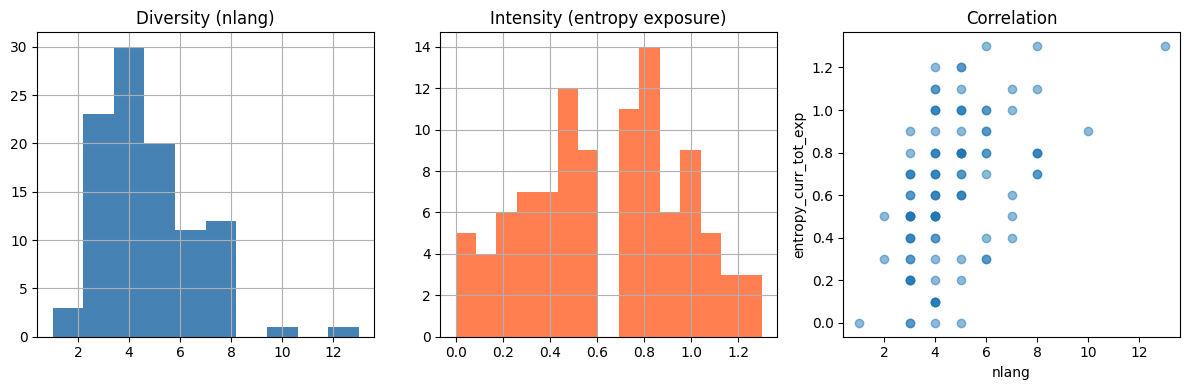

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

leapq = pd.read_csv(r'C:\Users\Aditi\ds005613\derivatives\nebula_101_leapq_data.tsv', sep='\t')

# Your two core predictors
print("=== DIVERSITY (nlang) ===")
print(leapq['nlang'].describe())
print(leapq['nlang'].value_counts().sort_index())

print("\n=== INTENSITY (entropy_curr_tot_exp) ===")
print(leapq['entropy_curr_tot_exp'].describe())

print("\n=== CORRELATION between them ===")
print(leapq[['nlang','entropy_curr_tot_exp']].corr())

# Compute raw summed exposure intensity as alternative
exp_cols = [c for c in leapq.columns if c.endswith('curr_tot_exp') 
            and c[0].isdigit()]
leapq['raw_intensity'] = leapq[exp_cols].sum(axis=1, skipna=True)
print("\n=== RAW INTENSITY (summed % exposure) ===")
print(leapq['raw_intensity'].describe())

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
leapq['nlang'].hist(ax=axes[0], bins=10, color='steelblue')
axes[0].set_title('Diversity (nlang)')
leapq['entropy_curr_tot_exp'].hist(ax=axes[1], bins=15, color='coral')
axes[1].set_title('Intensity (entropy exposure)')
axes[2].scatter(leapq['nlang'], leapq['entropy_curr_tot_exp'], alpha=0.5)
axes[2].set_xlabel('nlang')
axes[2].set_ylabel('entropy_curr_tot_exp')
axes[2].set_title('Correlation')
plt.tight_layout()
plt.savefig('predictor_distributions.png', dpi=150)
plt.show()

In [5]:
print("=== ENTROPY EXPOSURE (your intensity variable) ===")
print(leapq['entropy_curr_tot_exp'].describe())
print("\nSkewness:", leapq['entropy_curr_tot_exp'].skew())

print("\n=== CORRELATION: nlang vs entropy ===")
r = leapq['nlang'].corr(leapq['entropy_curr_tot_exp'])
print(f"Pearson r = {r:.3f}")

print("\n=== COVARIATES ===")
print(leapq[['age','edu']].describe())
print(leapq['sex'].value_counts())

=== ENTROPY EXPOSURE (your intensity variable) ===
count    101.000000
mean       0.635644
std        0.333342
min        0.000000
25%        0.400000
50%        0.700000
75%        0.900000
max        1.300000
Name: entropy_curr_tot_exp, dtype: float64

Skewness: -0.06906589925253953

=== CORRELATION: nlang vs entropy ===
Pearson r = 0.469

=== COVARIATES ===
              age         edu
count  101.000000  101.000000
mean    23.350495   15.742574
std      4.075626    2.364967
min     18.200000   11.000000
25%     20.800000   14.000000
50%     22.000000   16.000000
75%     24.800000   17.000000
max     38.500000   26.000000
sex
f    68
m    33
Name: count, dtype: int64


In [6]:
import pandas as pd
import numpy as np
from scipy import stats

leapq = pd.read_csv(r'C:\Users\Aditi\ds005613\derivatives\nebula_101_leapq_data.tsv', sep='\t')

# Encode sex as binary
leapq['sex_binary'] = (leapq['sex'] == 'f').astype(int)

# Z-score continuous predictors and covariates
leapq['nlang_z'] = stats.zscore(leapq['nlang'])
leapq['entropy_z'] = stats.zscore(leapq['entropy_curr_tot_exp'])
leapq['age_z'] = stats.zscore(leapq['age'])
leapq['edu_z'] = stats.zscore(leapq['edu'])
# TIV will be added after CAT12 runs — leave a placeholder column for now

# Save the shared design matrix — everyone loads THIS file
design = leapq[['participant_id', 'nlang', 'entropy_curr_tot_exp',
                 'age', 'edu', 'sex_binary',
                 'nlang_z', 'entropy_z', 'age_z', 'edu_z']].copy()

design.to_csv(r'C:\Users\Aditi\ds005613\shared_design_matrix.csv', index=False)
print("Saved. Shape:", design.shape)
print(design.head())

Saved. Shape: (101, 10)
  participant_id  nlang  entropy_curr_tot_exp   age  edu  sex_binary  \
0      sub-pp128      1                   0.0  26.5   16           0   
1      sub-pp107      2                   0.3  24.3   19           0   
2      sub-pp050      2                   0.5  21.5   15           1   
3      sub-pp171      3                   0.8  26.1   17           0   
4      sub-pp147      3                   0.0  27.2   15           1   

    nlang_z  entropy_z     age_z     edu_z  
0 -2.044703  -1.916392  0.776620  0.109393  
1 -1.491043  -1.011927  0.234134  1.384236  
2 -1.491043  -0.408950 -0.456304 -0.315555  
3 -0.937384   0.495516  0.677986  0.534340  
4 -0.937384  -1.916392  0.949230 -0.315555  


Median nlang: 4.0
diversity_group
low     56
high    45
Name: count, dtype: int64

=== T-TESTS: High vs Low Diversity (nlang) ===
  entropy_curr_tot_exp: t=4.527, p=0.0000
  age: t=0.265, p=0.7913
  edu: t=1.849, p=0.0674

=== T-TESTS: High vs Low Entropy ===
  nlang: t=4.576, p=0.0000
  age: t=1.093, p=0.2769
  edu: t=0.885, p=0.3784

=== SEX DIFFERENCES ===
  nlang: male mean=4.94, female mean=4.57, t=0.950, p=0.3446
  entropy_curr_tot_exp: male mean=0.68, female mean=0.61, t=0.969, p=0.3347

=== CORRELATIONS ===
                      nlang  entropy_curr_tot_exp    age    edu
nlang                 1.000                 0.469  0.120  0.324
entropy_curr_tot_exp  0.469                 1.000  0.010  0.078
age                   0.120                 0.010  1.000  0.713
edu                   0.324                 0.078  0.713  1.000

=== ANOVA: entropy across nlang categories ===
  F=11.124, p=0.0000
  low(1-3): n=26, mean entropy=0.419
  mid(4-5): n=50, mean entropy=0.658
  high(6+): n=25

C:\Users\Aditi\AppData\Local\Temp\ipykernel_54036\4031743332.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g['entropy_curr_tot_exp'].dropna() for _, g in leapq.groupby('nlang_cat')]
C:\Users\Aditi\AppData\Local\Temp\ipykernel_54036\4031743332.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, g in leapq.groupby('nlang_cat'):


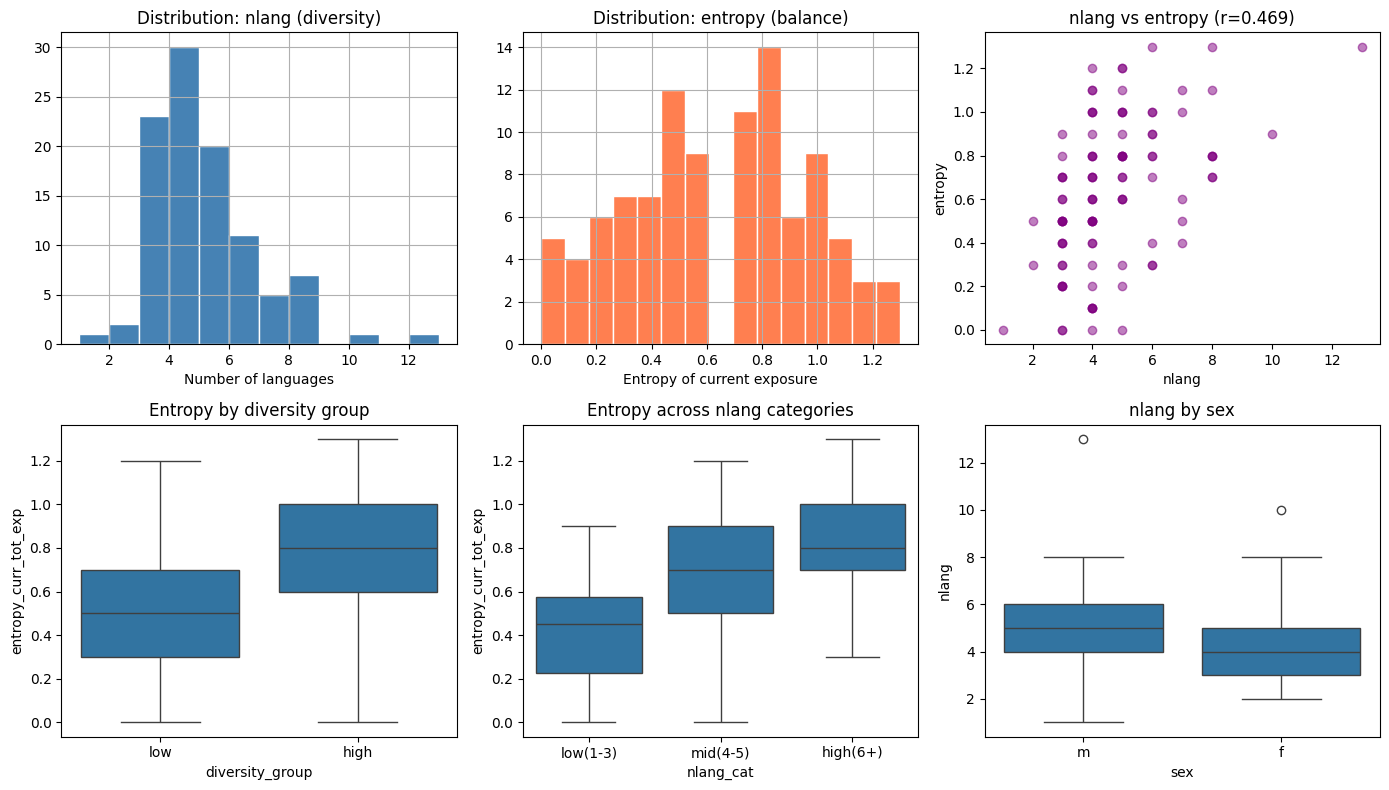

In [7]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

leapq = pd.read_csv(r'C:\Users\Aditi\ds005613\derivatives\nebula_101_leapq_data.tsv', sep='\t')
leapq['sex_binary'] = (leapq['sex'] == 'f').astype(int)

# ── 1. Split into low vs high diversity groups (median split on nlang) ──
median_nlang = leapq['nlang'].median()
leapq['diversity_group'] = np.where(leapq['nlang'] > median_nlang, 'high', 'low')
print(f"Median nlang: {median_nlang}")
print(leapq['diversity_group'].value_counts())

low_div  = leapq[leapq['diversity_group'] == 'low']
high_div = leapq[leapq['diversity_group'] == 'high']

# ── 2. Split into low vs high entropy groups (median split) ──
median_ent = leapq['entropy_curr_tot_exp'].median()
leapq['entropy_group'] = np.where(leapq['entropy_curr_tot_exp'] > median_ent, 'high', 'low')
low_ent  = leapq[leapq['entropy_group'] == 'low']
high_ent = leapq[leapq['entropy_group'] == 'high']

# ── 3. T-tests: does high nlang group differ from low on entropy, age, edu? ──
print("\n=== T-TESTS: High vs Low Diversity (nlang) ===")
for var in ['entropy_curr_tot_exp', 'age', 'edu']:
    t, p = stats.ttest_ind(high_div[var].dropna(), low_div[var].dropna())
    print(f"  {var}: t={t:.3f}, p={p:.4f}")

# ── 4. T-tests: does high entropy group differ on nlang, age, edu? ──
print("\n=== T-TESTS: High vs Low Entropy ===")
for var in ['nlang', 'age', 'edu']:
    t, p = stats.ttest_ind(high_ent[var].dropna(), low_ent[var].dropna())
    print(f"  {var}: t={t:.3f}, p={p:.4f}")

# ── 5. Sex differences in nlang and entropy ──
print("\n=== SEX DIFFERENCES ===")
for var in ['nlang', 'entropy_curr_tot_exp']:
    male = leapq[leapq['sex']=='m'][var].dropna()
    female = leapq[leapq['sex']=='f'][var].dropna()
    t, p = stats.ttest_ind(male, female)
    print(f"  {var}: male mean={male.mean():.2f}, female mean={female.mean():.2f}, t={t:.3f}, p={p:.4f}")

# ── 6. Pearson correlations of key variables ──
print("\n=== CORRELATIONS ===")
vars_of_interest = ['nlang', 'entropy_curr_tot_exp', 'age', 'edu']
corr_matrix = leapq[vars_of_interest].corr()
print(corr_matrix.round(3))

# ── 7. One-way ANOVA across nlang groups (1-3, 4-5, 6+) ──
leapq['nlang_cat'] = pd.cut(leapq['nlang'], bins=[0,3,5,13], labels=['low(1-3)','mid(4-5)','high(6+)'])
groups = [g['entropy_curr_tot_exp'].dropna() for _, g in leapq.groupby('nlang_cat')]
F, p = stats.f_oneway(*groups)
print(f"\n=== ANOVA: entropy across nlang categories ===")
print(f"  F={F:.3f}, p={p:.4f}")
for name, g in leapq.groupby('nlang_cat'):
    print(f"  {name}: n={len(g)}, mean entropy={g['entropy_curr_tot_exp'].mean():.3f}")

# ── 8. Spearman correlation (non-parametric, given ordinal nature of nlang) ──
print("\n=== SPEARMAN CORRELATIONS (non-parametric) ===")
rho, p = stats.spearmanr(leapq['nlang'], leapq['entropy_curr_tot_exp'])
print(f"  nlang vs entropy: rho={rho:.3f}, p={p:.4f}")
rho2, p2 = stats.spearmanr(leapq['nlang'], leapq['age'])
print(f"  nlang vs age: rho={rho2:.3f}, p={p2:.4f}")
rho3, p3 = stats.spearmanr(leapq['entropy_curr_tot_exp'], leapq['edu'])
print(f"  entropy vs edu: rho={rho3:.3f}, p={p3:.4f}")

# ── 9. Visualization ──
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Distribution plots
leapq['nlang'].hist(ax=axes[0,0], bins=12, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribution: nlang (diversity)')
axes[0,0].set_xlabel('Number of languages')

leapq['entropy_curr_tot_exp'].hist(ax=axes[0,1], bins=15, color='coral', edgecolor='white')
axes[0,1].set_title('Distribution: entropy (balance)')
axes[0,1].set_xlabel('Entropy of current exposure')

axes[0,2].scatter(leapq['nlang'], leapq['entropy_curr_tot_exp'], alpha=0.5, color='purple')
axes[0,2].set_xlabel('nlang')
axes[0,2].set_ylabel('entropy')
axes[0,2].set_title(f'nlang vs entropy (r=0.469)')

# Group comparisons
sns.boxplot(data=leapq, x='diversity_group', y='entropy_curr_tot_exp', ax=axes[1,0])
axes[1,0].set_title('Entropy by diversity group')

sns.boxplot(data=leapq, x='nlang_cat', y='entropy_curr_tot_exp', ax=axes[1,1])
axes[1,1].set_title('Entropy across nlang categories')

sns.boxplot(data=leapq, x='sex', y='nlang', ax=axes[1,2])
axes[1,2].set_title('nlang by sex')

plt.tight_layout()
plt.savefig(r'C:\Users\Aditi\ds005613\behavioral_stats.png', dpi=150)
plt.show()